# Compare results across hyperparameters
Collect performance information like F1 scores for a given model architecture while varying the hyperparameters in the objective function that weight the weak and self-supervised terms; plot performance several different ways in a heatmap format

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import seaborn as sns

from daart.data import DataGenerator, compute_sequence_pad
from daart.eval import get_precision_recall, run_lengths
from daart.io import get_expt_dir
from daart.transforms import ZScore

from daart_utils.data import DataHandler
from daart_utils.models import compute_model_predictions, get_default_hparams
from daart_utils.paths import data_path, results_path
from daart_utils.plotting import plot_heatmaps

In [5]:
# save predicted states from models
save_states = True
# overwrite predicted states from models
overwrite_states = False
# compute state statistics like median bout duration and behavior ratios
compute_state_stats = False

dataset = 'fly-5'
input_type = 'markers'
# input_type = 'features-simba'
sequence_length = 2000
batch_size = 8
ignore_background = True
anneal_start = 25
anneal_end = 75

if dataset == 'fish':
    from daart_utils.session_ids.fish import SESS_IDS_TRAIN_10, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_10[0]
    sequence_length = 1000
    input_type = 'features'
elif dataset == 'fly' or dataset == 'fly-4' or dataset == 'fly-5':
    from daart_utils.session_ids.fly import SESS_IDS_TRAIN_5, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_5[0]
elif dataset == 'ibl':
    from daart_utils.session_ids.ibl import SESS_IDS_TRAIN_5, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_5[0]
elif dataset == 'mouse-oft' or dataset == 'mouse-oft-aligned':
    from daart_utils.session_ids.oft import SESS_IDS_TRAIN_10, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_10[0]
    sequence_length = 500
    anneal_start, anneal_end = 10, 50
    #     input_type = 'features-sturman'
elif dataset == 'resident-intruder':
    from daart_utils.session_ids.resident_intruder import SESS_IDS_TRAIN_9, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_9[0]
#     input_type = 'features'
    anneal_start, anneal_end = 10, 50
elif dataset == 'calms21':
    from daart_utils.session_ids.calms21 import SESS_IDS_TRAIN_10, SESS_IDS_TEST
    sess_ids = SESS_IDS_TRAIN_10[0]
    sequence_length = 500
    input_type = 'features-simba'
    
# test datasets
sess_ids_test = SESS_IDS_TEST
# sess_ids_test = SESS_IDS_TRAIN_5[0]  # 9[0][:3]
# sess_ids_test = SESS_IDS_TRAIN_10[0]

expt_dir = get_expt_dir(os.path.join(results_path, dataset), sess_ids)
print(expt_dir)

# ATTN: need to set these params to match models that were fit
lambda_weak = [0, 0.1, 0.5, 1, 5]  # use this for lambda_task also, will handle below
lambda_strong = 1
lambda_pred = [0, 0.1, 0.5, 1, 5]

ss_algo = 'weak'  # 'weak' | 'pseudo_labels' | 'task'

# fill out hparams
backbone = 'dtcn'
# tt_expt_dir = 'var-test'  # fish
# tt_expt_dir = 'ssl_test'  # fly, ibl
# tt_expt_dir = '2-good_sample-0_%s' % input_type  # oft
tt_expt_dir = '5-good_sample-0_%s' % input_type  # ri
hparams = get_default_hparams(
    backbone=backbone, device='cuda', n_lags=4, input_type=input_type,
    sequence_length=sequence_length, batch_size=batch_size, 
    anneal_start=anneal_start, anneal_end=anneal_end, prob_threshold=0.9,  # pseudo_labels params
    variational=False,
)
hparams['sequence_pad'] = compute_sequence_pad(hparams)
hparams['tt_expt_dir'] = os.path.join(expt_dir, backbone, tt_expt_dir)
if ss_algo == 'weak' or ss_algo == 'task':
    hparams['semi_supervised_algo'] = None
else:
    hparams['semi_supervised_algo'] = ss_algo

model_types = [backbone]

metrics_df = []

for sess_id_test in sess_ids_test:
    
    # initialize data handler; point to correct base path
    handler = DataHandler(sess_id_test, base_path=os.path.join(data_path, dataset))
    if input_type == 'markers':
        markers_file = handler.get_marker_filepath()
    else:
        markers_file = handler.get_feature_filepath(dirname=input_type)

    # define data generator signals
    signals = ['markers']
    transforms = [ZScore()]
    paths = [markers_file]

    # build data generator
    data_gen_test = DataGenerator(
        [sess_id_test], [signals], [transforms], [paths], device=hparams['device'], 
        sequence_length=hparams['sequence_length'], batch_size=1,
        trial_splits=hparams['trial_splits'], 
        sequence_pad=hparams['sequence_pad'], input_type=hparams['input_type'])
    print('----------------------------')
    print(data_gen_test)
    print('----------------------------')
    print('\n')

    # load hand labels
    handler.load_hand_labels()
    states = np.argmax(handler.hand_labels.vals, axis=1)
    cutoff = int(np.floor(states.shape[0] / hparams['sequence_length'])) * hparams['sequence_length']
    states = states[:cutoff]
    label_names = handler.hand_labels.names
    n_classes = len(label_names) - 1 if ignore_background else len(label_names)
    counts = np.zeros(len(label_names))
    counts_ = np.bincount(states)
    counts[:counts_.shape[0]] = counts_

    # load heuristic labels
    handler.load_heuristic_labels()
    states_h = np.argmax(handler.heuristic_labels.vals, axis=1)
    states_heuristic = states_h[:cutoff]

    # -----------------------------------------
    # collect results
    # -----------------------------------------        
    for lw in lambda_weak:
        for lp in lambda_pred:

            if ss_algo == 'task':
                hparams['lambda_task'] = lw
                hparams['lambda_weak'] = 0
            else:
                hparams['lambda_task'] = 0
                hparams['lambda_weak'] = lw
            hparams['lambda_pred'] = lp
            
            # f1, precision, accuracy
            scores = {m: None for m in model_types}
            # ratio of time spent in each state
            ratios = {m: None for m in model_types}
            # median bout length for each state
            bout_lens = {m: None for m in model_types}

            # load/compute predictions
            try:
                predictions = compute_model_predictions(
                    hparams, data_gen_test, save_states=save_states, 
                    overwrite_states=overwrite_states, verbose=False)
            except (FileNotFoundError, NotADirectoryError):
                continue

            # compute precision and recall for each behavior type (model)
            if not ignore_background:
                scores[backbone] = get_precision_recall(
                    states, predictions, background=None, n_classes=len(label_names))
            else:
                scores[backbone] = get_precision_recall(
                    states, predictions, background=0, n_classes=len(label_names) - 1)

            if compute_state_stats:
                ratios[backbone] = np.bincount(predictions) / len(predictions)
                bouts = run_lengths(predictions)
                bout_lens[backbone] = [np.median(a) for _, a in bouts.items()]
            else:
                ratios[backbone] = [None] * (len(label_names) + 1)
                bout_lens[backbone] = [None] * (len(label_names) + 1)

            # compute precision and recall for each behavior type (heuristic)
            if not ignore_background:
                scores['heuristic'] = get_precision_recall(
                    states, states_heuristic, background=None, n_classes=len(label_names))
            else:
                scores['heuristic'] = get_precision_recall(
                    states, states_heuristic, background=0, n_classes=len(label_names) - 1)

            # store
            if not ignore_background:
                for l, label_name in enumerate(label_names):
                    df_dict = {
                        'expt_id': sess_id_test,
                        'label': label_name,
                        'lambda_weak': lw,
                        'lambda_pred': lp,
                        'precision_heur': scores['heuristic']['precision'][l],
                        'recall_heur': scores['heuristic']['recall'][l],
                        'f1_heur': scores['heuristic']['f1'][l],
                    }
                    for m_type in model_types:
                        model_name = 'mlp' if m_type == 'temporal-mlp' else m_type
                        if counts[l] == 0:
                            df_dict['precision_%s' % model_name] = np.nan
                            df_dict['recall_%s' % model_name] = np.nan
                            df_dict['f1_%s' % model_name] = np.nan
                        else:
                            df_dict['precision_%s' % model_name] = scores[m_type]['precision'][l]
                            df_dict['recall_%s' % model_name] = scores[m_type]['recall'][l]
                            df_dict['f1_%s' % model_name] = scores[m_type]['f1'][l]
#                         df_dict['ratio_%s' % model_name] = ratios[m_type][l + 1]
#                         df_dict['bout_len_%s' % model_name] = bout_lens[m_type][l + 1]
                    metrics_df.append(pd.DataFrame(df_dict, index=[0]))
            else:
                for l, label_name in enumerate(label_names[1:]):
                    df_dict = {
                        'expt_id': sess_id_test,
                        'label': label_name,
                        'lambda_weak': lw,
                        'lambda_pred': lp,
                        'precision_heur': scores['heuristic']['precision'][l],
                        'recall_heur': scores['heuristic']['recall'][l],
                        'f1_heur': scores['heuristic']['f1'][l],
                    }
                    for m_type in model_types:
                        model_name = 'mlp' if m_type == 'temporal-mlp' else m_type
                        if counts[l+1] == 0:
                            df_dict['precision_%s' % model_name] = np.nan
                            df_dict['recall_%s' % model_name] = np.nan
                            df_dict['f1_%s' % model_name] = np.nan
                        else:
                            df_dict['precision_%s' % model_name] = scores[m_type]['precision'][l]
                            df_dict['recall_%s' % model_name] = scores[m_type]['recall'][l]
                            df_dict['f1_%s' % model_name] = scores[m_type]['f1'][l]
                        df_dict['ratio_%s' % model_name] = ratios[m_type][l + 1]
                        df_dict['bout_len_%s' % model_name] = bout_lens[m_type][l + 1]
                    metrics_df.append(pd.DataFrame(df_dict, index=[0]))

metrics_df = pd.concat(metrics_df)

/media/mattw/behavior/results/daart/fly-5/multi-0
----------------------------
Generator contains 1 SingleDataset objects:
2019_06_26_fly2
    signals: ['markers']
    transforms: OrderedDict([('markers', ZScore())])
    paths: OrderedDict([('markers', '/home/mattw/Dropbox/shared/segmentation-data/fly-5/markers/2019_06_26_fly2_labeled.h5')])

----------------------------


saving states to /media/mattw/behavior/results/daart/fly-5/multi-0/dtcn/5-good_sample-0_markers/version_14/2019_06_26_fly2_states.npy
saving states to /media/mattw/behavior/results/daart/fly-5/multi-0/dtcn/5-good_sample-0_markers/version_19/2019_06_26_fly2_states.npy
saving states to /media/mattw/behavior/results/daart/fly-5/multi-0/dtcn/5-good_sample-0_markers/version_24/2019_06_26_fly2_states.npy
saving states to /media/mattw/behavior/results/daart/fly-5/multi-0/dtcn/5-good_sample-0_markers/version_10/2019_06_26_fly2_states.npy
saving states to /media/mattw/behavior/results/daart/fly-5/multi-0/dtcn/5-good_sample-0_

### plot results: heat plots for single model

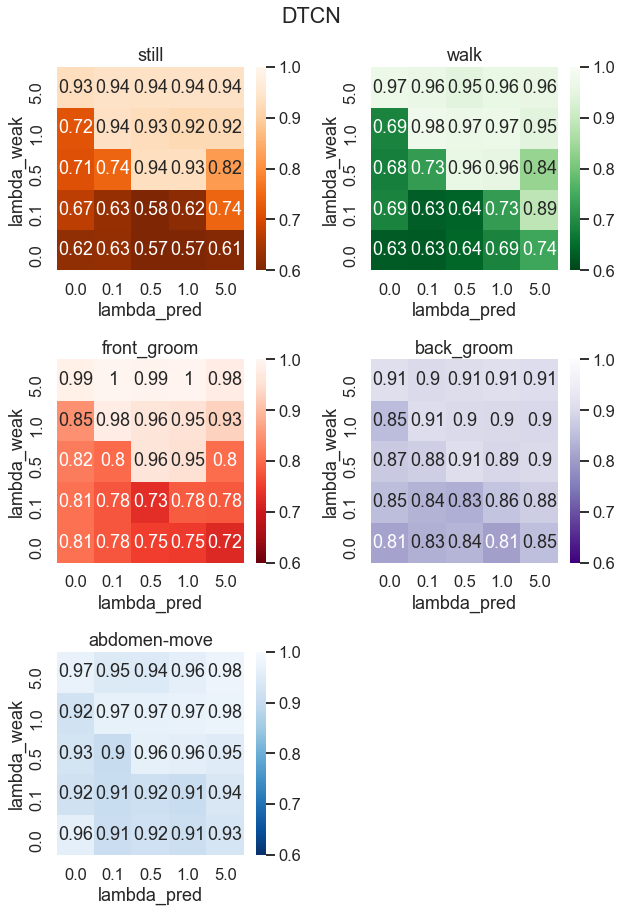

In [9]:
sns.set_context('talk')
sns.set_style('white')

metric = 'f1_dtcn'

# 1: by dataset/label
# 2: by label, avg over datasets
# 3: avg over dataset/label
plot_types = [2]

for plot_type in plot_types:
    annot = True #True if plot_type == 3 else False
    plot_heatmaps(
        df=metrics_df, metric=metric, sess_ids=sess_ids_test, 
        title=metric.split('_')[-1].upper(), kind=plot_type, 
        vmin=0.6, #.7, 
        vmax=1,
        annot=annot, 
        cmaps=['Oranges_r', 'Greens_r', 'Reds_r', 'Purples_r', 'Blues_r', 'Greys_r'],
#         save_file='/home/mattw/Dropbox/research-text/posters/2022_cosyne_daart/heatmaps_%s.pdf' % dataset
    )


### confusion matrix for a single model

In [4]:
# import torch
# from daart.io import get_expt_dir, find_experiment
# from daart.models import Segmenter

# # load model

# expt_dir = get_expt_dir(os.path.join(results_path, dataset), sess_ids)
# print(expt_dir)

# # fill out hparams
# model_type = 'dtcn'
# tt_expt_dir = 'test'
# hparams = get_default_hparams(
#     model_type=model_type, device='cuda', batch_size=batch_size, n_lags=4)
# hparams['lambda_weak'] = 0.5
# hparams['lambda_pred'] = 5
# hparams['batch_pad'] = compute_batch_pad(hparams)
# hparams['tt_expt_dir'] = os.path.join(expt_dir, model_type, tt_expt_dir)
# version_int = find_experiment(hparams, verbose=False)
# version_str = str('version_%i' % version_int)
# version_dir = os.path.join(hparams['tt_expt_dir'], version_str)
# model_file = os.path.join(version_dir, 'best_val_model.pt')
# arch_file = os.path.join(version_dir, 'hparams.pkl')
# print('Loading model defined in %s' % arch_file)
# with open(arch_file, 'rb') as f:
#     hparams_new = pickle.load(f)
# hparams_new['device'] = hparams.get('device', 'cpu')
# model_0 = Segmenter(hparams_new)
# model_0.load_state_dict(torch.load(
#     model_file, map_location=lambda storage, loc: storage))
# model_0.to(hparams_new['device'])
# model_0.eval()

In [5]:
# def confusion_matrix(true_states, inf_states, num_states):
#     confusion = np.zeros((num_states, num_states))
#     ztotal = np.zeros((num_states, 1))
#     for i in range(num_states):
#         for ztrue, zinf in zip(true_states, inf_states):
#             for j in range(num_states):
#                 confusion[i, j] += np.sum((ztrue == i) & (zinf == j))
#             ztotal[i] += np.sum(ztrue==i)
#     return confusion / ztotal

In [6]:
# states_hand = {}
# state_overlaps_0 = {}
# # state_overlaps_1 = {}
# state_probs_0 = {}
# # state_probs_1 = {}
# states_0 = {}
# # states_1 = {}
# state_overlaps = {}

# for expt_id in sess_ids_test:

#     print(expt_id)
    
#     # initialize data handler; point to correct base path
#     handler = DataHandler(expt_id, base_path=os.path.join(data_path, dataset))
#     if input_type == 'markers':
#         markers_file = handler.get_marker_filepath()
#     else:
#         markers_file = handler.get_feature_filepath(dirname=input_type)

#     # define data generator signals
#     signals = ['markers']
#     transforms = [ZScore()]
#     paths = [markers_file]

#     # build data generator
#     data_gen_test = DataGenerator(
#         [expt_id], [signals], [transforms], [paths], device=hparams['device'], 
#         batch_size=hparams['batch_size'], trial_splits=hparams['trial_splits'], 
#         batch_pad=hparams['batch_pad'], input_type=input_type)
#     print('----------------------------')
#     print(data_gen_test)
#     print('----------------------------')
#     print('\n')

#     # load hand labels
#     handler.load_hand_labels()
#     states = np.argmax(handler.hand_labels.vals, axis=1)
#     cutoff = int(np.floor(states.shape[0] / hparams['batch_size'])) * hparams['batch_size']
#     states = states[:cutoff]
#     states_hand[expt_id] = states
    
#     # compute predictions
#     print('computing predictions for model 0...', end='')
#     tmp = model_0.predict_labels(data_gen_test, return_scores=True)
#     labels_pred = np.vstack(tmp['labels'][0])
#     labels_model_ = np.argmax(labels_pred, axis=1)
#     probs_max = np.max(labels_pred, axis=1)
#     labels_model = np.copy(labels_model_)
#     # labels_model[probs_max < 0.75] = 0
#     state_probs_0[expt_id] = labels_pred
#     states_0[expt_id] = labels_model
#     print('done')
    
# #     print('computing predictions for model 1...', end='')
# #     tmp = model_1.predict_labels(data_gen_test, return_scores=True)
# #     labels_pred = np.vstack(tmp['labels'][0])
# #     labels_model_ = np.argmax(labels_pred, axis=1)
# #     probs_max = np.max(labels_pred, axis=1)
# #     labels_model = np.copy(labels_model_)
# #     # labels_model[probs_max < 0.75] = 0
# #     state_probs_1[expt_id] = labels_pred
# #     states_1[expt_id] = labels_model
# #     print('done\n')
    
#     state_overlaps_0[expt_id] = confusion_matrix(
#         [states[states > 0]], [states_0[expt_id][states > 0]], num_states=len(label_names))
    
# #     state_overlaps_1[expt_id] = confusion_matrix(
# #         [states[states > 0]], [states_1[expt_id][states > 0]], num_states=len(label_names))

In [7]:
# states_all_hand = []
# states_all_0 = []
# # states_all_1 = []

# for expt_id in sess_ids_test:
#     s = states_hand[expt_id]
#     states_all_hand.append(states_hand[expt_id][s > 0])
#     states_all_0.append(states_0[expt_id][s > 0])
# #     states_all_1.append(states_1[expt_id][s > 0])

# state_overlaps_all_0 = confusion_matrix(
#     states_all_hand, states_all_0, num_states=len(label_names))

# # state_overlaps_all_1 = confusion_matrix(
# #     states_all_hand, states_all_1, num_states=len(label_names))

In [8]:
# fig = plt.figure(figsize=(5, 5))
# im = plt.imshow(state_overlaps_all_0[1:, 1:], vmin=0, vmax=1, cmap='Greys_r')
# plt.title('Model 0')
# plt.yticks(np.arange(len(label_names)-1), label_names[1:])
# plt.xticks(np.arange(len(label_names)-1), label_names[1:], rotation=45, ha='right')
# plt.colorbar()
# # plt.savefig('/home/mattw/Dropbox/research-text/papers/2021-daart/figs/state_compare_w_wo_ab/model_0.pdf')
# plt.show()